# Collaborative Filtering 
There are two types of collaborativ  filtering this being user based collaborative filtering where we find users smiliar to you and predict based on what they like. There is also item based collaborative filtering where we find movies similar to the target movie and see how you rated those movies to see how you will predict this movie

In [60]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt  
import matplotlib.ticker as mticker     
import seaborn as sns 
import math 
import itertools 
from evaluation_code import rmse
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [61]:
# first lets load in our datasets 
train= pd.read_csv('data/train.csv') # user-movie interaction file with ratings we can train on
test_pairs= pd.read_csv('data/test_pairs.csv') # user-movie pairs we need to get ratings for, can also thing of predicting rank
movies = pd.read_csv('data/movies.csv')  # movie metadata
users = pd.read_csv('data/users.csv')  # user metadata

## Validation Split 
Explained in `baselineModel` notebook

In [62]:
def make_val_split(df, frac=0.20):
    """
    Temporal validation 20% split, can adjust based on the frac parameter 
    Sort ratings from old to new and hold out tail frac percent 
    """
    train_rows = []  # collect individual user training part 
    val_rows   = [] # collect individual validation part

    for user_id, group in df.groupby("user_id"):  # one group for each user_id, dont use actual user_id just want observations with that user_id       
        group = group.sort_values("timestamp") # sort it
        n = len(group) # how many ratings total user has given 
        n_val = math.ceil(frac * n) # how many validation observations will be used, use ciel to round up, defensive programming
        train_rows.append(group.iloc[:n - n_val]) # older 80% used for training using slicing
        val_rows.append(group.iloc[n - n_val:])  # newer 20% used for training using slicing

    my_train = pd.concat(train_rows).reset_index(drop=True)  # add to one dataframe for train
    my_val   = pd.concat(val_rows).reset_index(drop=True)   # one dataframe for val
    return my_train, my_val

In [63]:
training_set, validation_set = make_val_split(train) 

In [64]:
val_truth = validation_set[["user_id", "item_id", "rating"]]


## Redefine the Bias Model
The concept behind this model is fleshed out in the `baselineModel.ipynb`

In [65]:
# redefining the bias midel as a fallback for the item-cf
def fit_bias_model(train_df, mu, lambda_u=5, lambda_i=1, n_iter=20): # we have set lambdas for reguralization strength for each respective bias 
    """
    fit reguralized user and item bias using alternate updates over n_iter iterations
    Formula used: 
     b_i = sum_u(r_ui - mu - b_u) / (|count of ratings item i has recieved| + lambda_i)
     b_u = sum_i(r_ui - mu - b_i) / (|count of ratings user u has given| + lambda_u)
    """
    b_u = pd.Series(0.0, index=train_df["user_id"].unique()) # initialize at 0.
    b_i = pd.Series(0.0, index=train_df["item_id"].unique())

    df = train_df.copy()

    for i in range(n_iter): # n_iter is set at 20 so we run through 20 iterations 
        df["b_u"] = df["user_id"].map(b_u).fillna(0.0)
        df["residual_for_item"] = df["rating"] - mu - df["b_u"] # we get residual for each rating and  global mean subtracted by current user bias guess (start at 0)
        item_stats = df.groupby("item_id")["residual_for_item"].agg(["sum", "count"])  #aggregate sum of residuals and count of ratings per item for reguralized bias formula 
        b_i = item_stats["sum"] / (item_stats["count"] + lambda_i) # the reguralization formula

        # we are doing the same thing but for the item bias
        df["b_i"] = df["item_id"].map(b_i).fillna(0.0) 
        df["residual_for_user"] = df["rating"] - mu - df["b_i"]
        user_stats = df.groupby("user_id")["residual_for_user"].agg(["sum", "count"])
        b_u = user_stats["sum"] / (user_stats["count"] + lambda_u)

    return b_u, b_i


def predict_bias(pairs, mu, b_u, b_i):
    """
    predict ratings using actual bias formula μ + b_u + b_i

    """
    out = pairs[["user_id", "item_id"]].copy() # target pairs
    out["bu"] = out["user_id"].map(b_u).fillna(0.0) # look up the user bias and if not there fill with na 
    out["bi"] = out["item_id"].map(b_i).fillna(0.0) # look up item bias fill with 0 
    out["predicted_rating"] = (mu + out["bu"] + out["bi"]).clip(1.0, 5.0) # calculate predicted rating, clip from 1 to 5 to make sure doesnt exceed
    return out[["user_id", "item_id", "predicted_rating"]] # return what we need

In [66]:
global_mean = float(training_set["rating"].mean())
b_u, b_i = fit_bias_model(training_set, global_mean, lambda_u=5, lambda_i=1)

# Building the User-Item Rating Matrix 
We want to represent user u giving some iten i a rating of r for every single observation. This will result in a sparse matrix because most entries in this matrix will be empty as there a. 


In [67]:
def build_user_item_matrix(train_df):
    """
    Building a spase user-item utility matrix from our training set 
    We will return the csr matrix, user_to_id dictionary for lookup, item_to_id lookup, id_to_item lookup
    """
    user_ids = sorted(train_df["user_id"].unique()) # get all ser.item ids and sort them so order is same for differet runs 
    item_ids = sorted(train_df["item_id"].unique())

    user_to_id = {}
    for i, u in enumerate(user_ids): # get row index for each user_id
            user_to_id[u] = i

    item_to_id = {}
    for i, m in enumerate(item_ids): # get column index for each item_id
        item_to_id[m] = i

    id_to_item = {} 
    for m, i in item_to_id.items(): # get id to item
        id_to_item[i] = m

    rows = train_df["user_id"].map(user_to_id).values # convert the three columns to numpy arrays of matrix coordinates 
    cols = train_df["item_id"].map(item_to_id).values # .map() is dictionary lookup for ever row, values extracts numpy array 
    vals = train_df["rating"].values.astype(float) # .astype ti nake sure the ratings are floats consistent data type

    n_users = len(user_ids) # dimensions of matrix
    n_items = len(item_ids)

    R = csr_matrix((vals, (rows, cols)), shape=(n_users, n_items)) # csr matrix constructor 

    return R, user_to_id, item_to_id, id_to_item


In [68]:
R, user_to_id, item_to_id, id_to_item = build_user_item_matrix(training_set)

n_users, n_items = R.shape
density = R.nnz / (n_users * n_items)

print(f" matrix shape:{R.shape} (users × items)")
print(f" non-zero cells:{R.nnz:,}")
print(f" density: {density:.4%}")
print(f" sparsity: {1-density:.4%} of cells are empty")

 matrix shape:(6040, 3635) (users × items)
 non-zero cells:635,723
 density: 2.8955%
 sparsity: 97.1045% of cells are empty


## Mean Center Ratings
We mean center ratings to account for users who rate everything a 4 or 5 and the some users who only rate movies 2 or 3 so we get better signal off their ratings. \
\
Ex. Alice mean rating 4.5\
rated a 4: adjusted mean rating is -0.5 (negative signal)

In [69]:
def mean_center(R):
    R_c = R.copy().astype(float) # copy of csr Matrix so roiginal one is mot modifies

    row_sum = np.array(R_c.sum(axis=1)).flatten() # sum each row across the colmns, sum of all items for each user 
    row_count = np.array((R_c > 0).sum(axis=1)).flatten()  #count of ratings in a row, number of items user has rates
    user_mean = row_sum / np.maximum(row_count, 1) # get user mean rating

    for i in range(R_c.shape[0]):
        start = R_c.indptr[i] # row pointer array in csr format, for row i R_c.indptr[i] is the index in the data
        end = R_c.indptr[i + 1] # this is where it ends 
        if end > start:
            R_c.data[start:end] -= user_mean[i] # R_c.data[start:end] is the rating values for user i , mean center it 

    return R_c, user_mean


In [70]:
R_centered, user_means_arr = mean_center(R)

In [71]:
# we need to find item-item cosine similarity to find movies similar to the target movie, use how rated similar movies to using our centered utility 
# in this case similar means users who tended to rate two items similarly 
item_sim = cosine_similarity(R_centered.T)

# Bias-adjusted top-k prediction 
This is a hybrid reccomendation system that will be using a baseline bias model which we defined in the baseline notebook and the neighborhood based collaborative filtering approach with the cosine similarity we impe=lemented on the utility matrix.

main formula: 
`r̂(u,i) = mu + b_u + b_i + Σ[sim(i,j) × (r(u,j) − mu − b_u − b_j)] / Σ|sim(i,j)|`
where...
- mu = global mean rating 
- b_u = user bias 
- b_i = item bias 
- sim(i,j) = cosine similarity between item i (target) and item j (neighbor)
- r(u,j) = actual rating user u gave to neighbor j

We will find the neighbor movies (target item i only look at j moves that user u has already rates and have posotove cosine similarity to i, top K items), calculate residuals whichis the actual rating subtracted by the baseline prediction (calculated using the baseline notebook bias formula) 
\
Ex. 
- μ = 3.5 (average rating overall)
- b_u = +0.3 (Alice rates 0.3 higher than average)
- b_j = +0.4 (Movie Inception is 0.4 above average)
- Baseline prediction = 3.5 + 0.3 + 0.4 = 4.2
- Actual rating = 4.5
- Residual = 4.5 − 4.2 = +0.3

Then take weighted average of the residuals so we can get number that quantifies how much a user over/under rates movies like some movie i. 
Lastly we do a finla prediction using basline bias model and the collaborative filtering signal (weighted residuals of cosine similarity neighbors)

In [72]:
def predict_item_cf(pairs, R, item_sim, user_to_id, item_to_id, id_to_item, global_mean, b_u, b_i, K=20):
    predictions = [] # need to store predictions in a list

    for row in pairs.itertuples(index=False):  # iterate over datafrae rows, using tuples faster than rows
        user_id = row.user_id # get user and item id
        item_id = row.item_id

        b_u_val = float(b_u.get(user_id, 0.0)) # fallback for if user bias is 0, no in training 
        b_i_val = float(b_i.get(item_id, 0.0)) # item bias 0 for cold start
        baseline = global_mean + b_u_val + b_i_val # bias method prediction for fallback and combination

        # check cold-start items, item-to idx has no entry for it
        if item_id not in item_to_id:
            predictions.append(float(np.clip(baseline, 1.0, 5.0)))
            continue

        #cold start check for users should be okay
        if user_id not in user_to_id:
            predictions.append(float(np.clip(baseline, 1.0, 5.0)))
            continue

        user_id_index = user_to_id[user_id] # row index for user in sparse matriz
        item_id_index = item_to_id[item_id] # colum index for the target item

        rated_col_indices = R[user_id_index].indices # extract row of user id index from csr utility matrix as a row vector
        rated_raw_ratings = R[user_id_index].data # get raw rating values

        similar = item_sim[item_id_index, rated_col_indices] # index into the  similarity matrix for the row of the target item
        # how similar is target ite t other items user has rated?

        top_k_indices = np.argsort(similar)[::-1][:K] # return indices that sort similarities from small to large, reverse to get large to small, takes first K
        top_similars = similar[top_k_indices] # top K similarity scores
        top_ratings = rated_raw_ratings[top_k_indices] # raw ratings of K neighbor movies
        top_col_index = rated_col_indices[top_k_indices] # matrix column index of K neighbor item for lookup of item bias

        pos_mask = top_similars > 0 # filter for positive similarities only
        top_similars = top_similars[pos_mask]
        top_ratings = top_ratings[pos_mask]
        top_col_index = top_col_index[pos_mask]

        if len(top_similars) == 0: # if K neigbors has negative similarity fall back to bias model
            predictions.append(float(np.clip(baseline, 1.0, 5.0)))
            continue

        neighbor_item_ids = []
        for column in top_col_index:
            neighbor_item_ids.append(id_to_item[column])  # convert matrix column index back to the item_ids like before

        b_i_neighbors_list = [] #look up at item bias for each neighbor, we also use .get to handle any item not in bias dictionary
        for item_id in neighbor_item_ids:
            b_i_neighbors_list.append(float(b_i.get(item_id, 0.0)))
        b_i_neighbors = np.array(b_i_neighbors_list)

        residuals = top_ratings - (global_mean + b_u_val + b_i_neighbors) # top_ratings is what user gave to the neigboring items subtracted with what the bias model would have scored the neigboring movies

        numerator = np.dot(top_similars, residuals) # weighted sum of the similarity and residual for each number
        denominator = np.sum(np.abs(top_similars)) #abs value summation of similarity scores
        cf_signal = numerator / denominator # cf_signal we defined above

        pred = float(np.clip(baseline + cf_signal, 1.0, 5.0)) # get the predicted rating clip so its in right range
        predictions.append(pred) # add to list

    output_df = pairs[["user_id", "item_id"]].copy()
    output_df["predicted_rating"] = predictions # build the data frame
    return output_df

# Tune K Neighbor Amount
We are tuning how many similar neighbor movies to include in the weighted average. This is a hyperparameter to tune

In [73]:
K_values = [10, 20, 25, 30, 50]
k_results = []

# for loop to run through different K values
for K in K_values:
    print(f"K={K}")

    # input into our predict rating method
    prediction_k = predict_item_cf(
        validation_set[["user_id","item_id"]], R, item_sim,
        user_to_id, item_to_id, id_to_item,
        global_mean, b_u, b_i, K=K
    )

    # put into the set rmse function
    score_k = rmse(val_truth, prediction_k)
    print(f"RMSE = {score_k:.4f} ")
    k_results.append({"K": K, "val_rmse": score_k})

k_df = pd.DataFrame(k_results) # store in a dataframe 
best_K = int(k_df.loc[k_df["val_rmse"].idxmin(), "K"]) # index into lowest K value 
best_cf_rmse = float(k_df["val_rmse"].min()) # grab lowest rmse in the val_rmse column 
print(f"\n Best K: {best_K}, val RMSE: {best_cf_rmse:.4f}")

K=10


RMSE = 0.8916 
K=20
RMSE = 0.8811 
K=25
RMSE = 0.8800 
K=30
RMSE = 0.8798 
K=50
RMSE = 0.8803 

 Best K: 30, val RMSE: 0.8798


## Plot the K values against rmse

/var/folders/sz/_mlq7slj15vg1f70zg680jwr0000gn/T/ipykernel_15193/4041550758.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


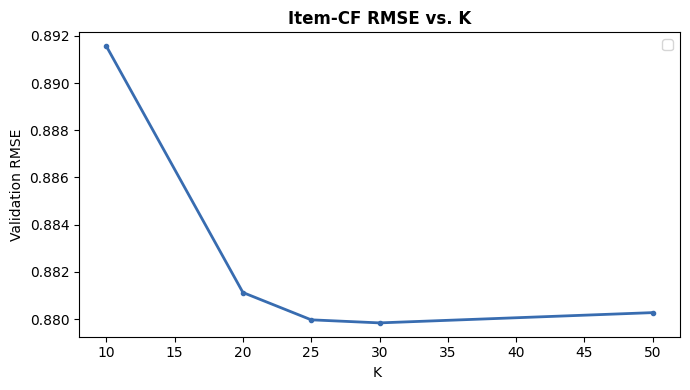

In [74]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_df["K"], k_df["val_rmse"], marker=".", color=sns.color_palette("Accent")[4], linewidth=2)
ax.set_xlabel("K ")
ax.set_ylabel("Validation RMSE")
ax.set_title("Item-CF RMSE vs. K", fontweight="bold")
ax.legend()
plt.tight_layout()

# Retrain on whole train.csv

In [77]:
global_mean_full = float(train["rating"].mean())

b_u_full, b_i_full = fit_bias_model(train, global_mean_full, lambda_u=5, lambda_i=1)

R_full, user_to_id_full, item_to_id_full, id_to_item_full = build_user_item_matrix(train)
R_full_center, user_mean_full = mean_center(R_full)

item_sim_full = cosine_similarity(R_full_center.T)

preds_cf_test = predict_item_cf(
    test_pairs, R_full, item_sim_full,
    user_to_id_full, item_to_id_full, id_to_item_full,
    global_mean_full, b_u_full, b_i_full, K=best_K
)

assert len(preds_cf_test) == len(test_pairs), "row count mismatch"
assert preds_cf_test["predicted_rating"].isna().sum() == 0, "NaN found"

preds_cf_test.to_csv("predictions_item_cf.csv", index=False)
